# Predicting Road Accident Risk – Data Cleaning

## 1. Introduction

Trong project **Predicting Road Accident Risk**, bước **Data Cleaning** được dùng để kiểm tra và làm sạch dữ liệu trước khi phân tích và xây dựng mô hình Machine Learning.

Dataset này mô tả nhiều yếu tố có thể ảnh hưởng đến rủi ro tai nạn giao thông, ví dụ như loại đường, số làn đường, độ cong của đường, giới hạn tốc độ, điều kiện ánh sáng, thời tiết, thời điểm trong ngày, ngày lễ, mùa đi học và số vụ tai nạn đã được ghi nhận.

Nếu dữ liệu có lỗi như missing values, duplicate rows, kiểu dữ liệu sai, nhãn không thống nhất hoặc giá trị bất hợp lý thì mô hình có thể học sai. Vì vậy, data cleaning giúp dữ liệu trở nên chính xác, nhất quán và sẵn sàng cho các bước tiếp theo như EDA, normalization, encoding và model training.


## 2. Import Libraries and Load Dataset

Đầu tiên, ta import các thư viện cần thiết và đọc file CSV bằng `pandas`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
# File CSV nên đặt cùng thư mục với file notebook này
df = pd.read_csv('Predicting_Road_Accident_Risk.csv')

# Hiển thị 5 dòng đầu tiên
df.head()


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


## 3. Check Dataset Shape and Basic Information

Ta kiểm tra số dòng, số cột và thông tin cơ bản của dataset để hiểu cấu trúc dữ liệu.


In [2]:
print("Number of rows and columns:")
print(df.shape)

print("\nDataset information:")
df.info()


Number of rows and columns:
(517754, 14)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  str    
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  str    
 6   weather                 517754 non-null  str    
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  str    
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk         

Dataset có **517,754 dòng** và **14 cột**. Các cột bao gồm dữ liệu số, dữ liệu dạng chữ và dữ liệu boolean (`True/False`).


In [3]:
# Xem thống kê cơ bản của các cột số
df.describe()


,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849975,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


## 4. Check Duplicate Rows

Duplicate rows là các dòng bị lặp lại hoàn toàn. Nếu có nhiều dòng trùng lặp, mô hình có thể bị ảnh hưởng vì một số bản ghi được học nhiều lần hơn bình thường.


In [4]:
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)


Number of duplicate rows: 0


Trong dataset này, số dòng trùng lặp là **0**, nên không cần xóa duplicate rows. Tuy nhiên, ta vẫn viết code xóa duplicate để đảm bảo an toàn nếu dataset được cập nhật sau này.


In [5]:
# Remove duplicate rows if any
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (517754, 14)


## 5. Identify Column Data Types

Ở bước này, ta phân loại cột thành numerical columns và categorical columns. Việc này giúp ta biết cột nào cần kiểm tra bằng thống kê, cột nào cần kiểm tra nhãn dữ liệu.


In [6]:
print(df.dtypes)


id                          int64
road_type                     str
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                      str
weather                       str
road_signs_present           bool
public_road                  bool
time_of_day                   str
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
dtype: object


In [7]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object' or df[col].dtype == 'bool']
num_cols = [col for col in df.columns if col not in cat_cols]

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)


Categorical columns:
['road_signs_present', 'public_road', 'holiday', 'school_season']

Numerical columns:
['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting', 'weather', 'time_of_day', 'num_reported_accidents', 'accident_risk']


Các cột categorical/boolean gồm:

- `road_type`
- `lighting`
- `weather`
- `road_signs_present`
- `public_road`
- `time_of_day`
- `holiday`
- `school_season`

Các cột numerical gồm:

- `id`
- `num_lanes`
- `curvature`
- `speed_limit`
- `num_reported_accidents`
- `accident_risk`


## 6. Check Unique Values in Categorical Columns

Ta kiểm tra các giá trị khác nhau trong từng cột categorical. Mục đích là phát hiện lỗi như sai chính tả, viết hoa/viết thường không thống nhất hoặc dư khoảng trắng.


In [8]:
for col in cat_cols:
    print("\nColumn:", col)
    print(df[col].unique())
    print("Number of unique values:", df[col].nunique())



Column: road_signs_present
[False  True]
Number of unique values: 2

Column: public_road
[ True False]
Number of unique values: 2

Column: holiday
[False  True]
Number of unique values: 2

Column: school_season
[ True False]
Number of unique values: 2


Các giá trị categorical nhìn chung khá sạch và dễ hiểu. Ví dụ:

- `road_type`: urban, rural, highway
- `lighting`: daylight, dim, night
- `weather`: rainy, clear, foggy
- `time_of_day`: afternoon, evening, morning

Tuy nhiên, ta vẫn nên chuẩn hóa text để tránh lỗi do khoảng trắng hoặc chữ hoa/chữ thường.


## 7. Standardize Text Values

Dù dữ liệu nhìn khá sạch, ta vẫn chuẩn hóa các cột dạng chữ bằng cách đưa về chữ thường và xóa khoảng trắng ở đầu/cuối chuỗi.


In [9]:
text_cols = ['road_type', 'lighting', 'weather', 'time_of_day']

for col in text_cols:
    df[col] = df[col].str.lower()
    df[col] = df[col].str.strip()

# Kiểm tra lại sau khi chuẩn hóa
for col in text_cols:
    print("\nColumn:", col)
    print(df[col].unique())



Column: road_type
<StringArray>
['urban', 'rural', 'highway']
Length: 3, dtype: str

Column: lighting
<StringArray>
['daylight', 'dim', 'night']
Length: 3, dtype: str

Column: weather
<StringArray>
['rainy', 'clear', 'foggy']
Length: 3, dtype: str

Column: time_of_day
<StringArray>
['afternoon', 'evening', 'morning']
Length: 3, dtype: str


Bước này giúp dữ liệu thống nhất hơn. Ví dụ, nếu có giá trị như `" Urban "` hoặc `"URBAN"`, chúng sẽ được chuyển về `"urban"`.


## 8. Check Missing Values

Missing values là các giá trị bị thiếu trong dataset. Nếu không xử lý, chúng có thể làm lỗi chương trình hoặc làm mô hình học không tốt.


In [10]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64


In [11]:
missing_percent = (df.isnull().sum() / df.shape[0]) * 100
missing_percent = missing_percent.round(2)

print("Missing values percentage:")
print(missing_percent)


Missing values percentage:
id                        0.0
road_type                 0.0
num_lanes                 0.0
curvature                 0.0
speed_limit               0.0
lighting                  0.0
weather                   0.0
road_signs_present        0.0
public_road               0.0
time_of_day               0.0
holiday                   0.0
school_season             0.0
num_reported_accidents    0.0
accident_risk             0.0
dtype: float64


Dataset này không có missing values, vì vậy không cần thay thế hoặc xóa dòng bị thiếu dữ liệu.

Tuy nhiên, trong thực tế, nếu có missing values thì có thể xử lý như sau:

- Cột số: điền bằng median hoặc mean
- Cột categorical: điền bằng mode, tức giá trị xuất hiện nhiều nhất


In [ ]:
# Code xử lý missing values nếu có
# Trong dataset hiện tại không có missing values.

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:")
print(df.isnull().sum())


Missing values after handling:
id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64


## 9. Check Invalid or Unreasonable Values

Sau khi kiểm tra missing values, ta kiểm tra các giá trị bất hợp lý. Ví dụ:

- `num_lanes` không nên nhỏ hơn 1
- `curvature` nên nằm trong khoảng 0 đến 1
- `speed_limit` phải lớn hơn 0
- `num_reported_accidents` không được âm
- `accident_risk` nên nằm trong khoảng 0 đến 1


In [13]:
check_cols = ['num_lanes', 'curvature', 'speed_limit', 
              'num_reported_accidents', 'accident_risk']

print("Minimum and maximum values:")
for col in check_cols:
    print(col, "min:", df[col].min(), "max:", df[col].max())


Minimum and maximum values:
num_lanes min: 1 max: 4
curvature min: 0.0 max: 1.0
speed_limit min: 25 max: 70
num_reported_accidents min: 0 max: 7
accident_risk min: 0.0 max: 1.0


Kết quả cho thấy các giá trị trong dataset đều nằm trong phạm vi hợp lý:

- `num_lanes`: từ 1 đến 4
- `curvature`: từ 0.0 đến 1.0
- `speed_limit`: từ 25 đến 70
- `num_reported_accidents`: từ 0 đến 7
- `accident_risk`: từ 0.0 đến 1.0

Vì vậy, dataset không có lỗi giá trị nghiêm trọng. Dù vậy, ta vẫn viết điều kiện lọc để đảm bảo dữ liệu hợp lệ.


In [14]:
# Keep only valid values
df = df[df['num_lanes'] >= 1]
df = df[(df['curvature'] >= 0) & (df['curvature'] <= 1)]
df = df[df['speed_limit'] > 0]
df = df[df['num_reported_accidents'] >= 0]
df = df[(df['accident_risk'] >= 0) & (df['accident_risk'] <= 1)]

print("Shape after checking valid values:", df.shape)


Shape after checking valid values: (517754, 14)


## 10. Detect Outliers with Box Plot

Outliers là các giá trị rất khác biệt so với phần lớn dữ liệu. Trong bài toán tai nạn giao thông, outliers không phải lúc nào cũng là lỗi. Một số đoạn đường có thể thật sự nguy hiểm và có số vụ tai nạn cao hơn bình thường.

Vì vậy, ta chỉ kiểm tra outliers trước, không xóa ngay lập tức.


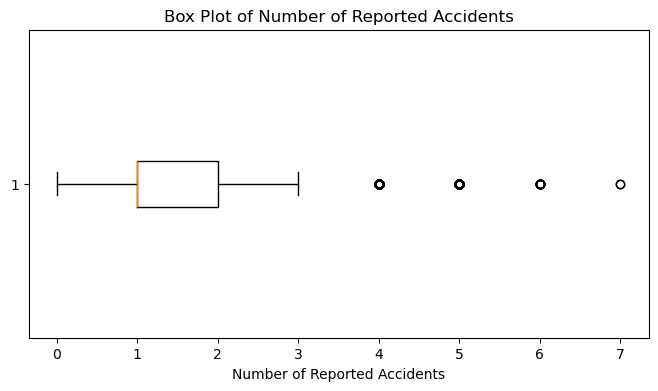

In [15]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['num_reported_accidents'], vert=False)
plt.xlabel('Number of Reported Accidents')
plt.title('Box Plot of Number of Reported Accidents')
plt.show()


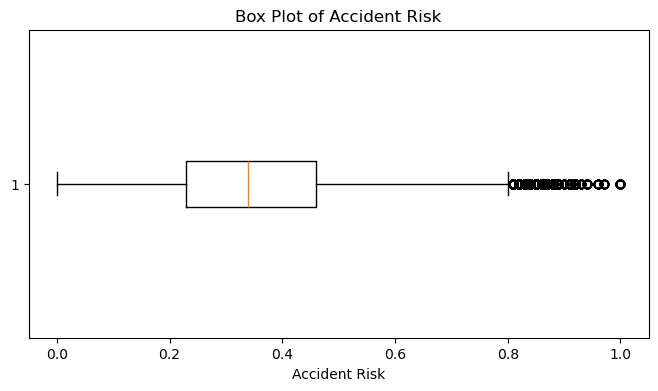

In [16]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['accident_risk'], vert=False)
plt.xlabel('Accident Risk')
plt.title('Box Plot of Accident Risk')
plt.show()


## 11. Detect Outliers Using IQR Method

IQR là một cách để phát hiện outliers. Công thức:

- `IQR = Q3 - Q1`
- `Lower Bound = Q1 - 1.5 * IQR`
- `Upper Bound = Q3 + 1.5 * IQR`

Ta áp dụng cho cột `num_reported_accidents` vì đây là cột có thể có giá trị cao bất thường.


In [17]:
Q1 = df['num_reported_accidents'].quantile(0.25)
Q3 = df['num_reported_accidents'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['num_reported_accidents'] < lower_bound) | 
              (df['num_reported_accidents'] > upper_bound)]

print("Number of outliers:", outliers.shape[0])


Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Bound: -0.5
Upper Bound: 3.5
Number of outliers: 2649


Mặc dù IQR có thể phát hiện một số giá trị là outliers, ta **không xóa ngay** vì giá trị cao trong `num_reported_accidents` có thể mang ý nghĩa quan trọng. Những đoạn đường có nhiều tai nạn thường là những điểm có rủi ro cao, rất cần thiết cho mô hình dự đoán.

Do đó, trong bài này, ta chỉ ghi nhận outliers và giữ lại dữ liệu.


In [18]:
# Không xóa outliers trong num_reported_accidents
# Vì số vụ tai nạn cao có thể là thông tin quan trọng để dự đoán accident_risk.

print("Shape after outlier checking:", df.shape)


Shape after outlier checking: (517754, 14)


## 12. Remove Unnecessary Column

Cột `id` chỉ là mã định danh cho từng dòng. Nó không mô tả điều kiện đường hoặc yếu tố gây tai nạn, nên không có nhiều ý nghĩa cho mô hình dự đoán.

Vì vậy, ta loại bỏ cột `id` trước khi chuẩn bị dữ liệu cho model.


In [19]:
df_clean = df.drop(columns=['id'])

df_clean.head()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


## 13. Check Cleaned Dataset Again

Sau khi làm sạch, ta kiểm tra lại dataset để đảm bảo không còn missing values, duplicate rows và dữ liệu vẫn đúng cấu trúc.


In [20]:
print("Cleaned dataset shape:")
print(df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())


Cleaned dataset shape:
(517754, 13)

Missing values after cleaning:
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

Duplicate rows after cleaning:
656


In [21]:
df_clean.head()


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


## 14. Separate Features and Target Variable

Trong bài toán này:

- `accident_risk` là target variable, tức biến cần dự đoán
- Các cột còn lại là features, tức dữ liệu đầu vào cho mô hình


In [22]:
X = df_clean.drop(columns=['accident_risk'])
y = df_clean['accident_risk']

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()


X shape: (517754, 12)
y shape: (517754,)


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1
1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0
2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2
3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1
4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1


In [23]:
y.head()


0    0.13
1    0.35
2    0.30
3    0.21
4    0.56
Name: accident_risk, dtype: float64

## 15. Save the Cleaned Dataset

Cuối cùng, ta lưu dataset đã làm sạch thành một file CSV mới để dùng cho các bước sau như EDA, Encoding, Normalization và Model Training.


In [24]:
df_clean.to_csv('Cleaned_Road_Accident_Risk.csv', index=False)

print("Cleaned dataset has been saved as Cleaned_Road_Accident_Risk.csv")


Cleaned dataset has been saved as Cleaned_Road_Accident_Risk.csv


## 16. Conclusion

Trong bước **Data Cleaning**, dataset Predicting Road Accident Risk đã được kiểm tra và xử lý cẩn thận. Dataset ban đầu có **517,754 dòng** và **14 cột**. Sau khi kiểm tra, dữ liệu không có missing values và không có duplicate rows.

Các cột categorical như `road_type`, `lighting`, `weather` và `time_of_day` được chuẩn hóa để đảm bảo tính nhất quán. Các cột numerical cũng được kiểm tra để phát hiện giá trị bất hợp lý. Kết quả cho thấy dữ liệu nằm trong phạm vi hợp lý.

Outliers được kiểm tra bằng box plot và IQR method. Tuy nhiên, các giá trị cao trong `num_reported_accidents` không bị xóa vì chúng có thể đại diện cho các đoạn đường nguy hiểm và có ý nghĩa quan trọng trong bài toán dự đoán rủi ro tai nạn.

Cột `id` được loại bỏ vì chỉ là mã định danh và không có giá trị dự đoán. Sau bước cleaning, dataset đã sẵn sàng cho các bước tiếp theo như Exploratory Data Analysis, Feature Engineering, Data Normalization và Model Training.
